# **Hotel Reviews: Hybrid Classification and Ensemble Methods**

Combining Random Forest + BERT for Optimal Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import Dataset
import pickle
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


## **1. Load Analyzed And Raw Datase**

In [2]:
hotel_raw = pd.read_csv('../data/processed/hotel_raw.csv')
hotel_clean = pd.read_csv('../data/processed/hotel_clean.csv')

# Extract text columns
hotel_text_raw = hotel_raw['text']
hotel_text_clean = hotel_clean['text']

print(f"Hotel data: {len(hotel_raw)} samples")
print(f"Label distribution: {hotel_raw['label'].value_counts()}")

Hotel data: 1600 samples
Label distribution: label
0    800
1    800
Name: count, dtype: int64


## **2. Feature Engineering**

In [4]:
def count_repeated_words(text):
    if not text:
        return 0
    words = text.split()
    word_counts = {}
    for word in words:
        word_counts[word] = word_counts.get(word, 0) + 1
    return sum(1 for count in word_counts.values() if count > 1)

def engineer_features(raw_df, clean_df):
    features_df = raw_df.copy()
    
    # Text length features
    features_df['text_length'] = raw_df['text'].str.len()
    features_df['word_count'] = raw_df['text'].str.split().str.len()
    features_df['avg_word_length'] = features_df['text_length'] / features_df['word_count']
    features_df['sentence_count'] = raw_df['text'].str.count(r'[.!?]') + 1
    features_df['avg_sentence_length'] = features_df['word_count'] / features_df['sentence_count']
    
    # Linguistic patterns
    features_df['exclamation_count'] = raw_df['text'].str.count('!')
    features_df['question_count'] = raw_df['text'].str.count(r'\?')
    features_df['uppercase_ratio'] = raw_df['text'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / len(x) if x else 0
    )
    features_df['digit_count'] = raw_df['text'].str.count(r'\d')
    
    # Sentiment features
    positive_words = ['good', 'great', 'excellent', 'amazing', 'love', 'perfect', 'best', 'wonderful']
    negative_words = ['bad', 'terrible', 'awful', 'hate', 'worst', 'horrible', 'disappointing']
    
    features_df['positive_word_count'] = raw_df['text'].apply(
        lambda x: sum(1 for word in positive_words if word in x.lower())
    )
    features_df['negative_word_count'] = raw_df['text'].apply(
        lambda x: sum(1 for word in negative_words if word in x.lower())
    )
    features_df['sentiment_ratio'] = features_df['positive_word_count'] / (
        features_df['negative_word_count'] + 1
    )
    
    # Content analysis
    features_df['unique_word_ratio'] = clean_df['text'].apply(
        lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
    )
    features_df['repeated_words'] = clean_df['text'].apply(count_repeated_words)
    
    return features_df

# Engineer features
hotel_features_df = engineer_features(hotel_raw, hotel_clean)
feature_cols = [col for col in hotel_features_df.columns if col not in ['text', 'label']]

## **3. Hotel Data Splitting**

In [5]:
X_text_raw = hotel_text_raw
X_text_clean = hotel_text_clean
X_features = hotel_features_df[feature_cols]
y = hotel_raw['label']

# Split data
(
    X_raw_train, X_raw_test,
    X_clean_train, X_clean_test,
    X_features_train, X_features_test,
    y_train, y_test
) = train_test_split(
    X_text_raw, X_text_clean, X_features, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(y_train)} samples")
print(f"Test set: {len(y_test)} samples")


Training set: 1280 samples
Test set: 320 samples


## **4. Load BERT and RF Models**

### 4.1 Download form Google

In [6]:
import gdown
def download_models_from_drive():
    """Download models from Google Drive using direct links"""
    # Create models directory
    os.makedirs('../models', exist_ok=True)

    # Google Drive file IDs (extract from your shareable links)
    # Example: https://drive.google.com/file/d/FILE_ID/view?usp=sharing
    DRIVE_FILES = {
        'random_forest_hotel.pkl': '1QH9hCytQJK9hBjRZ5W4K5djDS_KizrCv',
        # For BERT model folder, you'll need to zip it first and upload the zip
        'bert_hotel_baseline.zip': '1PvnOmsLYz3IDhkk8-KgAWndeNKfdd9he'
    }

    print("Downloading models from Google Drive...")
    for filename, file_id in DRIVE_FILES.items():
        if file_id == 'YOUR_LR_FILE_ID_HERE':  # Skip if not configured
            print(f"⚠️  Please configure Google Drive file ID for {filename}")
            continue
            
        output_path = f'../models/{filename}'
        
        if not os.path.exists(output_path):
            print(f"   Downloading {filename}...")
            url = f'https://drive.google.com/uc?id={file_id}'
            gdown.download(url, output_path, quiet=False)
        else:
            print(f"   ✅ {filename} already exists")
    
        # Extract BERT model if downloaded as zip
        if os.path.exists('../models/bert_hotel_baseline.zip'):
            import zipfile
            print("   📂 Extracting BERT model...")
            with zipfile.ZipFile('../models/bert_hotel_baseline.zip', 'r') as zip_ref:
                zip_ref.extractall('../models/')
            print("   ✅ BERT model extracted")

download_models_from_drive()


   ✅ random_forest_hotel.pkl already exists
   📂 Extracting BERT model...
   ✅ BERT model extracted
   ✅ bert_hotel_baseline.zip already exists
   📂 Extracting BERT model...
   ✅ BERT model extracted


### 4.2 Load RF

In [7]:
with open('../models/random_forest_hotel.pkl', 'rb') as f:
        hotel_rf_package = pickle.load(f)
print("Hotel Random Forest loaded")
    
# Extract components
hotel_rf_model = hotel_rf_package['model']
hotel_tfidf = hotel_rf_package['tfidf']
hotel_scaler = hotel_rf_package['scaler']

Hotel Random Forest loaded


### 4.3 Load Hotel BERT

In [9]:
try:
    # Load hotel-trained BERT
    hotel_bert_model  = AutoModelForSequenceClassification.from_pretrained(
        '../models/bert_hotel_baseline'
    )
    hotel_bert_tokenizer  = AutoTokenizer.from_pretrained('../models/bert_hotel_baseline')
    print("✅ Successfully loaded hotel-trained BERT model")
    
except Exception as e:
    print(f"⚠️  Could not load hotel BERT: {e}")

✅ Successfully loaded hotel-trained BERT model


## **4. BERT Embedding Extraction**

In [11]:
# Set up device for BERT operations
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device for embeddings: {device}")

Using device for embeddings: cuda


In [12]:
def get_bert_embeddings(texts, model, tokenizer, batch_size=16):
    """Extract BERT embeddings from the last hidden layer"""
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize batch
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )
            
            # Move to device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Get model outputs
            outputs = model(**inputs, output_hidden_states=True)
            
            # Extract [CLS] token embeddings from last hidden layer
            # Shape: (batch_size, hidden_size)
            cls_embeddings = outputs.hidden_states[-1][:, 0, :]
            
            embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(embeddings)

# Move BERT model to device
hotel_bert_model.to(device)

# Generate embeddings for train and test sets
print("Generating training embeddings...")
bert_embeddings_train = get_bert_embeddings(
    X_raw_train.tolist(), 
    hotel_bert_model, 
    hotel_bert_tokenizer,
    batch_size=16 if torch.cuda.is_available() else 8
)

print("Generating test embeddings...")
bert_embeddings_test = get_bert_embeddings(
    X_raw_test.tolist(), 
    hotel_bert_model, 
    hotel_bert_tokenizer,
    batch_size=16 if torch.cuda.is_available() else 8
)

print(f"BERT embeddings shape: Train={bert_embeddings_train.shape}, Test={bert_embeddings_test.shape}")


Generating training embeddings...


Generating embeddings: 100%|██████████| 80/80 [00:09<00:00,  8.48it/s]


Generating test embeddings...


Generating embeddings: 100%|██████████| 20/20 [00:02<00:00,  9.75it/s]

BERT embeddings shape: Train=(1280, 768), Test=(320, 768)


## **5. Train BERT Classifier Using Embeddings**

In [14]:
# Train a simple classifier on BERT embeddings
from sklearn.linear_model import LogisticRegression

bert_embedding_classifier = LogisticRegression(random_state=42, max_iter=1000)
bert_embedding_classifier.fit(bert_embeddings_train, y_train)

# Get predictions and probabilities
bert_embed_pred = bert_embedding_classifier.predict(bert_embeddings_test)
bert_embed_proba = bert_embedding_classifier.predict_proba(bert_embeddings_test)[:, 1]

# Evaluate BERT embedding classifier
bert_embed_accuracy = accuracy_score(y_test, bert_embed_pred)
bert_embed_f1 = f1_score(y_test, bert_embed_pred)
bert_embed_auc = roc_auc_score(y_test, bert_embed_proba)

print(f"BERT Embedding Classifier:")
print(f"  Accuracy: {bert_embed_accuracy:.4f}")
print(f"  F1-Score: {bert_embed_f1:.4f}")
print(f"  AUC-ROC: {bert_embed_auc:.4f}")

BERT Embedding Classifier:
  Accuracy: 0.8906
  F1-Score: 0.8923
  AUC-ROC: 0.9617


## **6. Random Forest Predictions**

In [15]:
# Prepare RF features
X_tfidf_train = hotel_tfidf.transform(X_clean_train)
X_tfidf_test = hotel_tfidf.transform(X_clean_test)
X_features_scaled_train = hotel_scaler.transform(X_features_train)
X_features_scaled_test = hotel_scaler.transform(X_features_test)
X_rf_combined_test = hstack([X_tfidf_test, X_features_scaled_test])

# Get RF predictions and probabilities
rf_pred = hotel_rf_model.predict(X_rf_combined_test)
rf_proba = hotel_rf_model.predict_proba(X_rf_combined_test)[:, 1]

# Evaluate RF
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  AUC-ROC: {rf_auc:.4f}")


Random Forest:
  Accuracy: 0.8438
  F1-Score: 0.8447
  AUC-ROC: 0.9172


## **7. Create Ensemble Methods**

In [16]:
class WeightedEnsemble:
    """Custom weighted ensemble classifier"""
    
    def __init__(self, rf_weight=0.5, bert_weight=0.5):
        self.rf_weight = rf_weight
        self.bert_weight = bert_weight
    
    def predict_proba(self, rf_proba, bert_proba):
        """Weighted average of probabilities"""
        return (self.rf_weight * rf_proba + self.bert_weight * bert_proba)
    
    def predict(self, rf_proba, bert_proba):
        """Predict based on weighted probabilities"""
        weighted_proba = self.predict_proba(rf_proba, bert_proba)
        return (weighted_proba > 0.5).astype(int)

In [17]:
class ConfidenceBasedEnsemble:
    """Ensemble that weights predictions based on model confidence"""
    
    def __init__(self, confidence_threshold=0.7):
        self.confidence_threshold = confidence_threshold
    
    def predict_proba(self, rf_proba, bert_proba):
        """Weight predictions based on confidence"""
        rf_confidence = np.abs(rf_proba - 0.5) * 2  # Distance from 0.5, scaled to [0,1]
        bert_confidence = np.abs(bert_proba - 0.5) * 2
        
        # Normalize weights
        total_confidence = rf_confidence + bert_confidence + 1e-8  # Avoid division by zero
        rf_weights = rf_confidence / total_confidence
        bert_weights = bert_confidence / total_confidence
        
        return rf_weights * rf_proba + bert_weights * bert_proba
    
    def predict(self, rf_proba, bert_proba):
        weighted_proba = self.predict_proba(rf_proba, bert_proba)
        return (weighted_proba > 0.5).astype(int)

### 7.1 Test different ensemble approaches

In [18]:

ensemble_methods = {
    'Equal Weight (50-50)': WeightedEnsemble(0.5, 0.5),
    'RF Favored (60-40)': WeightedEnsemble(0.6, 0.4),
    'BERT Favored (40-60)': WeightedEnsemble(0.4, 0.6),
    'Confidence Based': ConfidenceBasedEnsemble()
}

In [19]:
print("\nENSEMBLE EVALUATION:")

ensemble_results = {}
best_ensemble_f1 = 0
best_ensemble_name = ""

for name, ensemble in ensemble_methods.items():
    # Get ensemble predictions
    ensemble_proba = ensemble.predict_proba(rf_proba, bert_embed_proba)
    ensemble_pred = ensemble.predict(rf_proba, bert_embed_proba)
    
    # Evaluate
    accuracy = accuracy_score(y_test, ensemble_pred)
    f1 = f1_score(y_test, ensemble_pred)
    auc = roc_auc_score(y_test, ensemble_proba)
    
    ensemble_results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'predictions': ensemble_pred,
        'probabilities': ensemble_proba
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC-ROC: {auc:.4f}")
    
    if f1 > best_ensemble_f1:
        best_ensemble_f1 = f1
        best_ensemble_name = name

print(f"\nBest Ensemble: {best_ensemble_name} (F1: {best_ensemble_f1:.4f})")


ENSEMBLE EVALUATION:

Equal Weight (50-50):
  Accuracy: 0.8938
  F1-Score: 0.8951
  AUC-ROC: 0.9487

RF Favored (60-40):
  Accuracy: 0.8938
  F1-Score: 0.8951
  AUC-ROC: 0.9486

BERT Favored (40-60):
  Accuracy: 0.8906
  F1-Score: 0.8923
  AUC-ROC: 0.9498

Confidence Based:
  Accuracy: 0.8938
  F1-Score: 0.8951
  AUC-ROC: 0.9452

Best Ensemble: Equal Weight (50-50) (F1: 0.8951)


## **8. Comprehensive Model Comparison**

In [20]:
# Compile all results
all_models = {
    'Random Forest': {
        'accuracy': rf_accuracy,
        'f1_score': rf_f1,
        'auc_roc': rf_auc,
        'type': 'Traditional ML'
    },
    'BERT Embeddings': {
        'accuracy': bert_embed_accuracy,
        'f1_score': bert_embed_f1,
        'auc_roc': bert_embed_auc,
        'type': 'Deep Learning'
    }
}


In [21]:
# Add ensemble results
for name, results in ensemble_results.items():
    all_models[f'Ensemble: {name}'] = {
        'accuracy': results['accuracy'],
        'f1_score': results['f1_score'],
        'auc_roc': results['auc_roc'],
        'type': 'Ensemble'
    }

In [22]:
# Display comparison table
print("\n" + "="*90)
print("COMPREHENSIVE MODEL COMPARISON - HOTEL REVIEW CLASSIFICATION")
print("="*90)
print(f"{'Model':<35} {'Type':<15} {'Accuracy':<10} {'F1-Score':<10} {'AUC-ROC':<10}")
print("-" * 90)

for model_name, metrics in all_models.items():
    print(f"{model_name:<35} {metrics['type']:<15} {metrics['accuracy']:<10.4f} {metrics['f1_score']:<10.4f} {metrics['auc_roc']:<10.4f}")



COMPREHENSIVE MODEL COMPARISON - HOTEL REVIEW CLASSIFICATION
Model                               Type            Accuracy   F1-Score   AUC-ROC   
------------------------------------------------------------------------------------------
Random Forest                       Traditional ML  0.8438     0.8447     0.9172    
BERT Embeddings                     Deep Learning   0.8906     0.8923     0.9617    
Ensemble: Equal Weight (50-50)      Ensemble        0.8938     0.8951     0.9487    
Ensemble: RF Favored (60-40)        Ensemble        0.8938     0.8951     0.9486    
Ensemble: BERT Favored (40-60)      Ensemble        0.8906     0.8923     0.9498    
Ensemble: Confidence Based          Ensemble        0.8938     0.8951     0.9452    


## **9.  Model Complementarity Analysis**

In [24]:
def analyze_prediction_patterns(rf_pred, bert_pred, y_true, model1_name="RF", model2_name="BERT"):
    """Analyze where models agree/disagree and their individual strengths"""
    
    # Agreement analysis
    agreement = (rf_pred == bert_pred)
    agreement_rate = np.mean(agreement)
    
    print(f"\nMODEL AGREEMENT ANALYSIS:")
    print(f"   Agreement rate: {agreement_rate:.3f} ({np.sum(agreement)}/{len(agreement)} predictions)")
    
    # When they agree, accuracy
    agree_mask = agreement
    if np.sum(agree_mask) > 0:
        agree_accuracy = accuracy_score(y_true[agree_mask], rf_pred[agree_mask])
        print(f"   Accuracy when agreeing: {agree_accuracy:.4f}")
    
    # When they disagree, who's right?
    disagree_mask = ~agreement
    if np.sum(disagree_mask) > 0:
        disagree_count = np.sum(disagree_mask)
        print(f"   Disagreement cases: {disagree_count}")
        
        # Check who's right when they disagree
        rf_correct_disagree = np.sum((rf_pred[disagree_mask] == y_true[disagree_mask]))
        bert_correct_disagree = np.sum((bert_pred[disagree_mask] == y_true[disagree_mask]))
        
        print(f"   {model1_name} correct when disagreeing: {rf_correct_disagree}/{disagree_count} ({rf_correct_disagree/disagree_count:.3f})")
        print(f"   {model2_name} correct when disagreeing: {bert_correct_disagree}/{disagree_count} ({bert_correct_disagree/disagree_count:.3f})")
    
    # Individual model strengths
    print(f"\nINDIVIDUAL MODEL STRENGTHS:")
    
    # RF unique correct predictions
    rf_unique_correct = (rf_pred == y_true) & (bert_pred != y_true)
    bert_unique_correct = (bert_pred == y_true) & (rf_pred != y_true)
    
    print(f"   {model1_name} uniquely correct: {np.sum(rf_unique_correct)} cases")
    print(f"   {model2_name} uniquely correct: {np.sum(bert_unique_correct)} cases")
    
    return {
        'agreement_rate': agreement_rate,
        'agree_accuracy': agree_accuracy if np.sum(agree_mask) > 0 else None,
        'rf_unique_correct': np.sum(rf_unique_correct),
        'bert_unique_correct': np.sum(bert_unique_correct)
    }

# Analyze RF vs BERT complementarity
complementarity_analysis = analyze_prediction_patterns(
    rf_pred, bert_embed_pred, y_test, "Random Forest", "BERT Embeddings"
)


MODEL AGREEMENT ANALYSIS:
   Agreement rate: 0.853 (273/320 predictions)
   Accuracy when agreeing: 0.9304
   Disagreement cases: 47
   Random Forest correct when disagreeing: 16/47 (0.340)
   BERT Embeddings correct when disagreeing: 31/47 (0.660)

INDIVIDUAL MODEL STRENGTHS:
   Random Forest uniquely correct: 16 cases
   BERT Embeddings uniquely correct: 31 cases


## **10. Visualization: ROC curves**

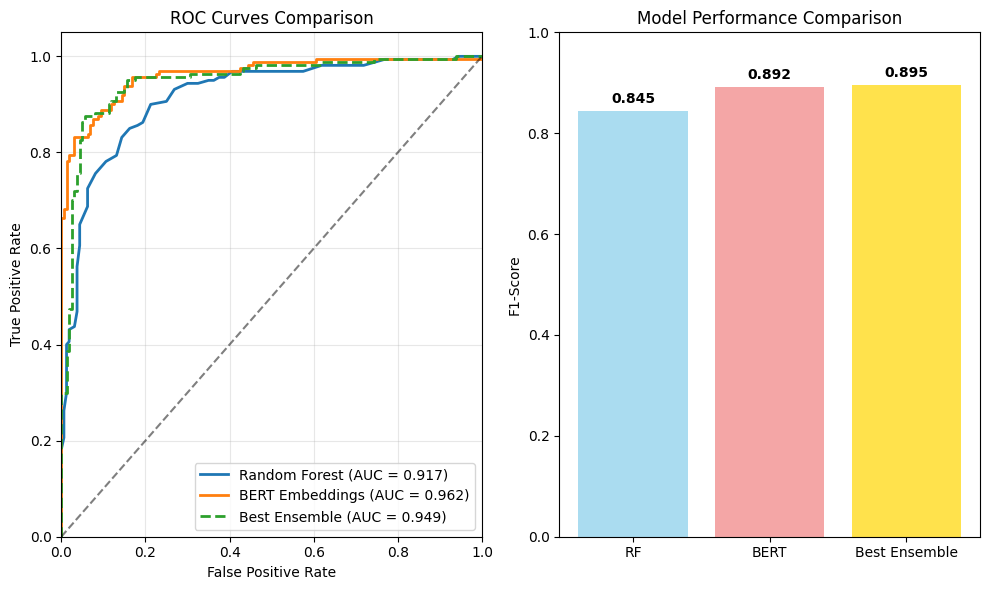

In [25]:
# Calculate ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
bert_fpr, bert_tpr, _ = roc_curve(y_test, bert_embed_proba)

# Best ensemble ROC
best_ensemble_proba = ensemble_results[best_ensemble_name]['probabilities']
ensemble_fpr, ensemble_tpr, _ = roc_curve(y_test, best_ensemble_proba)

# Plot ROC curves
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)
plt.plot(bert_fpr, bert_tpr, label=f'BERT Embeddings (AUC = {bert_embed_auc:.3f})', linewidth=2)
plt.plot(ensemble_fpr, ensemble_tpr, label=f'Best Ensemble (AUC = {ensemble_results[best_ensemble_name]["auc_roc"]:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Performance comparison bar chart
plt.subplot(1, 2, 2)
models = ['RF', 'BERT', 'Best Ensemble']
f1_scores = [rf_f1, bert_embed_f1, best_ensemble_f1]
colors = ['skyblue', 'lightcoral', 'gold']

bars = plt.bar(models, f1_scores, color=colors, alpha=0.7)
plt.ylabel('F1-Score')
plt.title('Model Performance Comparison')
plt.ylim([0, 1])

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/ensemble_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## **13. Export Models**

In [37]:
# Create directories for Phase 3 exports
os.makedirs('../embeddings', exist_ok=True)
os.makedirs('../results/hybrid_classification', exist_ok=True)

### Export 1: Complete ensemble pipeline

In [38]:

ensemble_package = {
    'rf_model': hotel_rf_model,
    'rf_tfidf': hotel_tfidf, 
    'rf_scaler': hotel_scaler,
    'bert_model': hotel_bert_model,
    'bert_tokenizer': hotel_bert_tokenizer,
    'bert_classifier': bert_embedding_classifier,
    'ensemble_method': 'equal_weight',
    'weights': {'rf': 0.5, 'bert': 0.5},
    'performance': {
        'rf_f1': rf_f1,
        'bert_f1': bert_embed_f1, 
        'ensemble_f1': best_ensemble_f1,
        'improvement': best_ensemble_f1 - max(rf_f1, bert_embed_f1)
    },
    'feature_cols': feature_cols
}

with open('../models/complete_ensemble_pipeline.pkl', 'wb') as f:
    pickle.dump(ensemble_package, f)
print("✅ Complete ensemble pipeline exported")

✅ Complete ensemble pipeline exported


### Export 2: BERT embeddings for clustering

In [33]:

np.save('../embeddings/hotel_bert_train_embeddings.npy', bert_embeddings_train)
np.save('../embeddings/hotel_bert_test_embeddings.npy', bert_embeddings_test)

embeddings_metadata = {
    'train_shape': bert_embeddings_train.shape,
    'test_shape': bert_embeddings_test.shape, 
    'embedding_dim': bert_embeddings_train.shape[1],
    'train_labels': y_train.values,
    'test_labels': y_test.values,
    'train_texts': X_raw_train.tolist(),
    'test_texts': X_raw_test.tolist()
}

with open('../embeddings/hotel_embeddings_metadata.pkl', 'wb') as f:
    pickle.dump(embeddings_metadata, f)
print("✅ BERT embeddings and metadata exported")


✅ BERT embeddings and metadata exported


### Export 3: All predictions for optimization

In [35]:
predictions_package = {
    'rf_predictions': rf_pred,
    'rf_probabilities': rf_proba,
    'bert_predictions': bert_embed_pred,
    'bert_probabilities': bert_embed_proba,
    'ensemble_predictions': ensemble_results[best_ensemble_name]['predictions'],
    'ensemble_probabilities': ensemble_results[best_ensemble_name]['probabilities'],
    'true_labels': y_test.values,
    'test_texts': X_raw_test.tolist(),
    'agreement_mask': (rf_pred == bert_embed_pred),
    'confidence_scores': np.abs(ensemble_results[best_ensemble_name]['probabilities'] - 0.5) * 2
}

with open('../results/hybrid_classification/all_predictions_for_optimization.pkl', 'wb') as f:
    pickle.dump(predictions_package, f)
print("✅ Model predictions for optimization exported")

✅ Model predictions for optimization exported


### Export 4: Feature importance for dual-weight system

In [36]:

feature_names = list(hotel_tfidf.get_feature_names_out()) + feature_cols
feature_importance_package = {
    'feature_names': feature_names,
    'rf_importances': hotel_rf_model.feature_importances_,
    'top_features': dict(zip(
        [feature_names[i] for i in np.argsort(hotel_rf_model.feature_importances_)[::-1][:20]],
        sorted(hotel_rf_model.feature_importances_, reverse=True)[:20]
    )),
    'tfidf_feature_count': len(hotel_tfidf.get_feature_names_out()),
    'engineered_feature_count': len(feature_cols)
}

with open('../results/hybrid_classification/feature_importance_for_clustering.pkl', 'wb') as f:
    pickle.dump(feature_importance_package, f)
print("✅ Feature importance for clustering exported")

✅ Feature importance for clustering exported
